Sample of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst pe

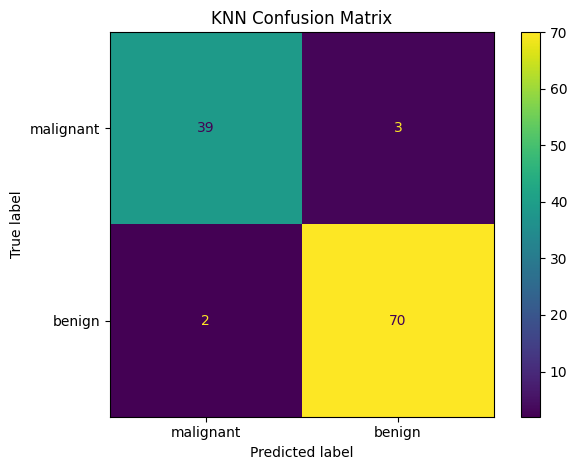

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

# Display dataset information
print("Sample of the dataset:")
print(X.head())

print("\nDataset shape:")
print(X.shape)

print("\nClass balance:")
print(y.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy, 4))

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.savefig("week6_knn_confusion_matrix.png", dpi=150)

print("\nSaved confusion matrix image.")


Accuracy for different K values:
K = 1: Accuracy = 0.9386
K = 2: Accuracy = 0.9298
K = 3: Accuracy = 0.9825
K = 4: Accuracy = 0.9474
K = 5: Accuracy = 0.9561
K = 6: Accuracy = 0.9561
K = 7: Accuracy = 0.9737
K = 8: Accuracy = 0.9737
K = 9: Accuracy = 0.9737
K = 10: Accuracy = 0.9649
K = 11: Accuracy = 0.9737
K = 12: Accuracy = 0.9737
K = 13: Accuracy = 0.9737
K = 14: Accuracy = 0.9649
K = 15: Accuracy = 0.9737

Saved K comparison graph.


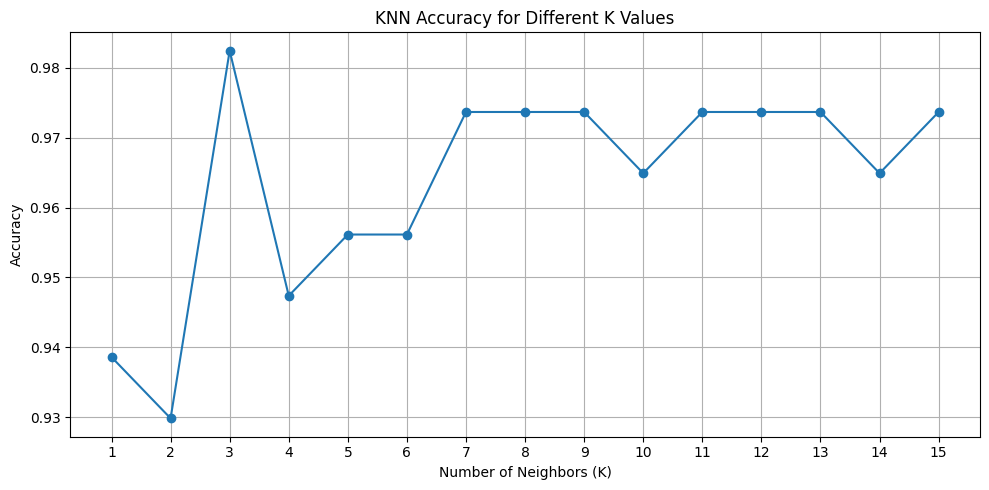

In [2]:
# Compare different values of K

k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, prediction))

print("Accuracy for different K values:")

for k, acc in zip(k_values, accuracies):
    print(f"K = {k}: Accuracy = {acc:.4f}")

# Plot K versus accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.savefig("week6_knn_k_comparison.png", dpi=150)

print("\nSaved K comparison graph.")
